# LangChain Orchestrator Trace Analysis
Visualize per-query timing breakdowns from `--trace-output` JSON files.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 6)})

# Pipeline stages that sum to `total` in the trace JSON.
STAGES = ["web_search", "fetch_url", "summarize", "llm_inference"]
COLORS = {
    "web_search": "#4e79a7",
    "fetch_url": "#f28e2b",
    "summarize": "#e15759",
    "llm_inference": "#76b7b2",
}

# Additional exact per-request vLLM metrics (seconds) captured from HTTP headers.
LLM_METRICS = ["llm_ttft", "llm_e2e", "llm_queue", "llm_prefill", "llm_decode"]

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Load trace file — change path here to analyze different runs
TRACE_FILE = "/tmp/trace_real_b128.json"

with open(TRACE_FILE) as f:
    data = json.load(f)

df = pd.DataFrame(data["traces"])
print(f"Benchmark: {data['benchmark']}")
print(f"Batch size: {data['batch_size']}")
print(f"Total wall time: {data['total_wall_time']:.2f}s")
print(f"Queries: {len(df)}")
df[STAGES + ["total"]].describe().round(3)

Benchmark: haystack/queries.txt
Batch size: 128
Total wall time: 250.74s
Queries: 128


,web_search,fetch_url,summarize,llm_inference,total
count,128.000,128.000,128.000,128.000,128.000
mean,4.609,16.669,9.926,16.654,47.857
std,0.481,4.842,18.627,5.519,20.602
min,2.360,4.831,0.319,0.735,18.915
25%,4.453,13.860,7.236,14.165,43.778
50%,4.642,16.338,8.989,15.755,46.768
75%,4.763,19.114,10.070,17.550,49.124
max,6.087,36.798,216.239,37.067,259.859


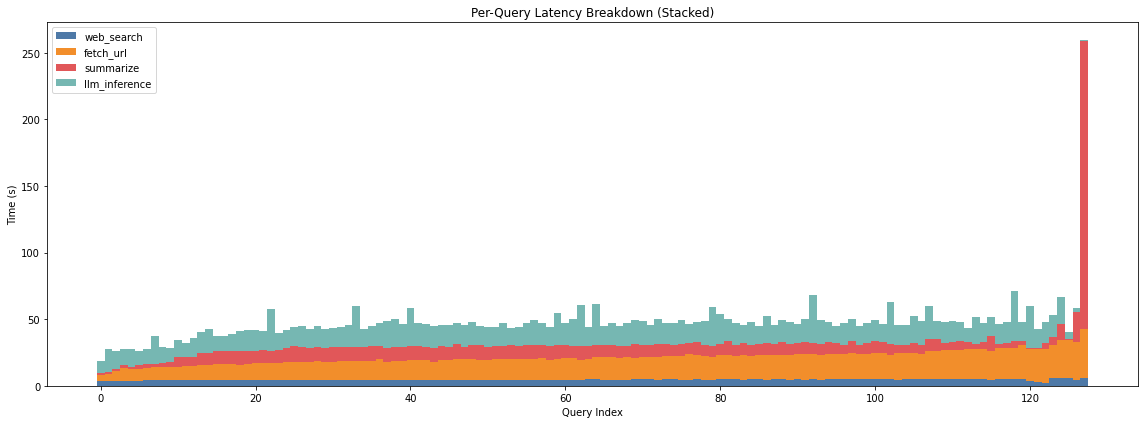

In [3]:
# 1. Stacked bar chart — per-query stage breakdown
fig, ax = plt.subplots(figsize=(16, 6))
bottom = pd.Series(0.0, index=df.index)
for stage in STAGES:
    ax.bar(df["query_idx"], df[stage], bottom=bottom, label=stage, color=COLORS[stage], width=1.0)
    bottom += df[stage]
ax.set_xlabel("Query Index")
ax.set_ylabel("Time (s)")
ax.set_title("Per-Query Latency Breakdown (Stacked)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("per_query_stacked.png", bbox_inches="tight")
plt.show()

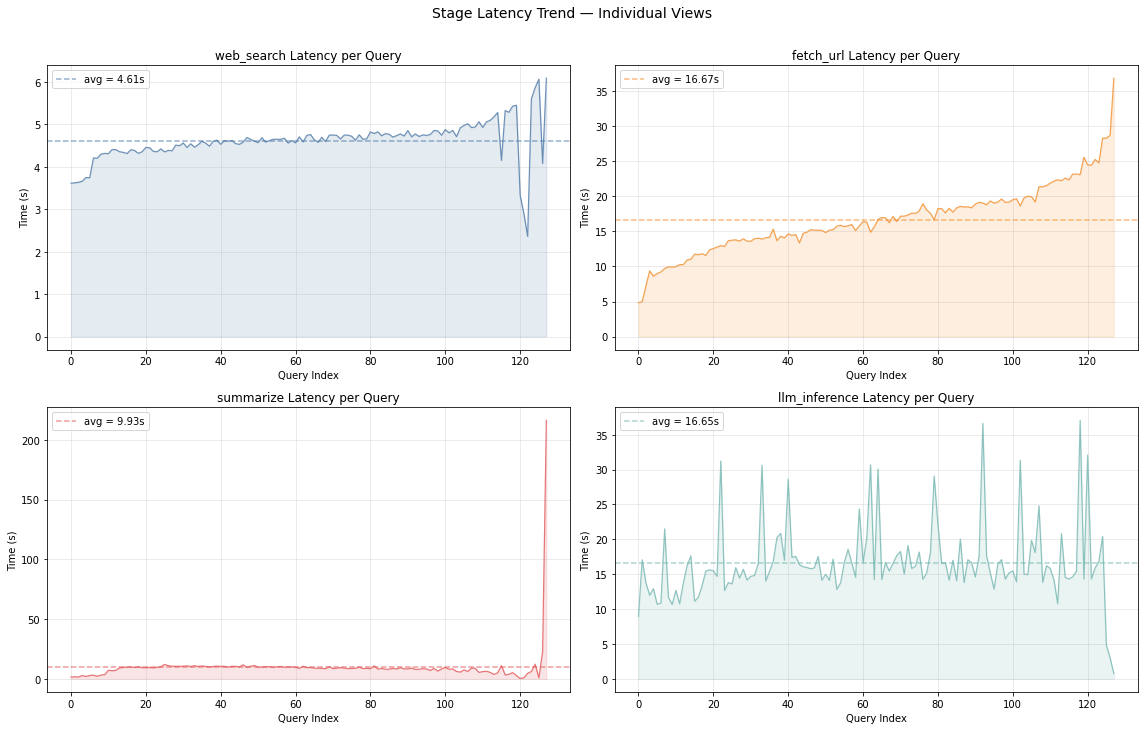

In [9]:
# 2. Individual line chart per stage
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, stage in enumerate(STAGES):
    ax = axes[i]
    ax.plot(df["query_idx"], df[stage], color=COLORS[stage], alpha=0.8, linewidth=1.2)
    ax.fill_between(df["query_idx"], df[stage], alpha=0.15, color=COLORS[stage])
    avg = df[stage].mean()
    ax.axhline(avg, color=COLORS[stage], linestyle="--", alpha=0.6, label=f"avg = {avg:.2f}s")
    ax.set_xlabel("Query Index")
    ax.set_ylabel("Time (s)")
    ax.set_title(f"{stage} Latency per Query")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle("Stage Latency Trend — Individual Views", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("stage_latency_individual.png", bbox_inches="tight")
plt.show()

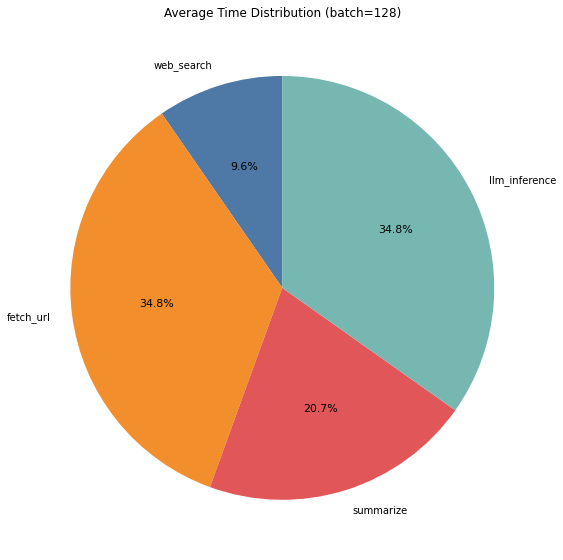

In [5]:
# 3. Pie chart — average time share per stage
avg_times = df[STAGES].mean()
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    avg_times, labels=STAGES, autopct="%1.1f%%",
    colors=[COLORS[s] for s in STAGES], startangle=90
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title(f"Average Time Distribution (batch={data['batch_size']})")
plt.tight_layout()
plt.savefig("time_distribution_pie.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_768648/845518400.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


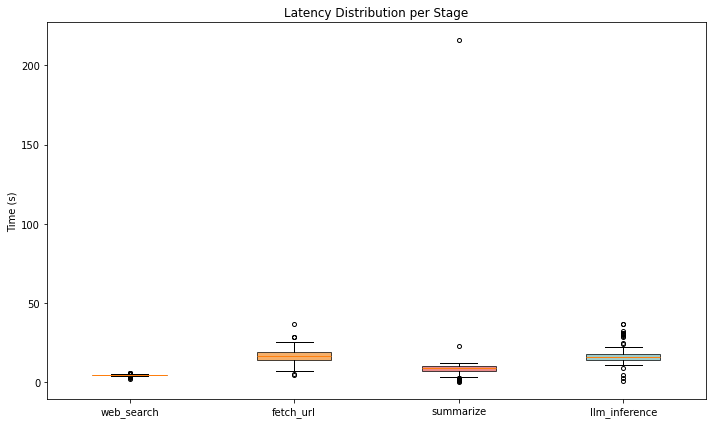

In [6]:
# 4. Box plot — latency distribution per stage
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    [df[s] for s in STAGES], labels=STAGES, patch_artist=True,
    showfliers=True, flierprops={"marker": "o", "markersize": 4}
)
for patch, stage in zip(bp["boxes"], STAGES):
    patch.set_facecolor(COLORS[stage])
    patch.set_alpha(0.7)
ax.set_ylabel("Time (s)")
ax.set_title("Latency Distribution per Stage")
plt.tight_layout()
plt.savefig("latency_boxplot.png", bbox_inches="tight")
plt.show()

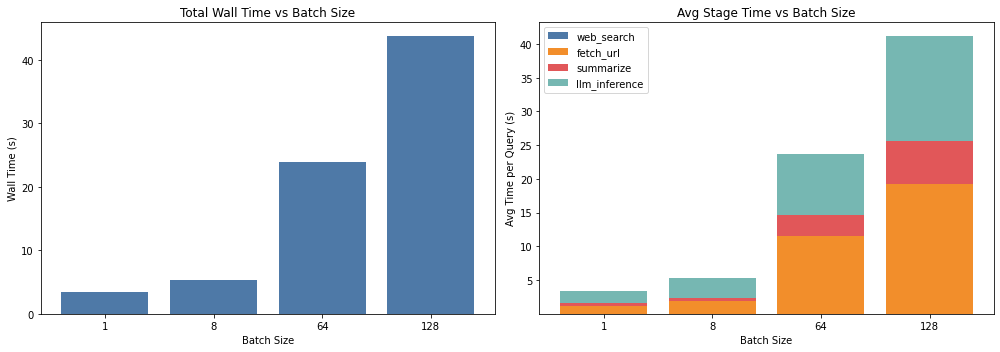

 batch_size  wall_time  web_search_avg  fetch_url_avg  summarize_avg  llm_inference_avg
          1   3.446686    1.000000e-06       1.189882       0.353860           1.899062
          8   5.328163    8.750000e-07       1.887263       0.503020           2.918548
         64  23.983781    7.343750e-07      11.567770       3.122564           8.995076
        128  43.705389    1.179688e-06      19.273284       6.344695          15.531715


In [7]:
# 5. Compare multiple trace files (batch size comparison)
trace_files = {
    "batch_1": "/tmp/trace_b1.json",
    "batch_8": "/tmp/trace_b8.json",
    "batch_64": "/tmp/trace_b64.json",
    "batch_128": "/tmp/trace_b128.json",
}

comparison = []
for label, path in trace_files.items():
    if Path(path).exists():
        with open(path) as f:
            d = json.load(f)
        tdf = pd.DataFrame(d["traces"])
        row = {"batch_size": d["batch_size"], "wall_time": d["total_wall_time"]}
        for s in STAGES:
            row[f"{s}_avg"] = tdf[s].mean()
        comparison.append(row)

cdf = pd.DataFrame(comparison)
if not cdf.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: wall time vs batch size
    axes[0].bar(cdf["batch_size"].astype(str), cdf["wall_time"], color="#4e79a7")
    axes[0].set_xlabel("Batch Size")
    axes[0].set_ylabel("Wall Time (s)")
    axes[0].set_title("Total Wall Time vs Batch Size")

    # Right: stacked avg stage times
    bottom = pd.Series(0.0, index=cdf.index)
    for stage in STAGES:
        col = f"{stage}_avg"
        axes[1].bar(cdf["batch_size"].astype(str), cdf[col], bottom=bottom, label=stage, color=COLORS[stage])
        bottom += cdf[col]
    axes[1].set_xlabel("Batch Size")
    axes[1].set_ylabel("Avg Time per Query (s)")
    axes[1].set_title("Avg Stage Time vs Batch Size")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("batch_comparison.png", bbox_inches="tight")
    plt.show()
    print(cdf.to_string(index=False))
else:
    print("No comparison trace files found.")

In [8]:
# 6. Top 10 slowest queries
slowest = df.nlargest(10, "total")[["query_idx", "query", "total"] + STAGES]
slowest["query"] = slowest["query"].str[:60]
slowest.reset_index(drop=True)

,query_idx,query,total,web_search,fetch_url,summarize,llm_inference
0,127,which great river flows south through the nort...,259.859039,6.086796,36.798091,216.238675,0.735477
1,118,where does the most metabolic activity in the ...,70.806432,5.427395,23.060273,5.251846,37.066918
2,92,who plays lucas in days of our lives?,68.389820,4.772767,19.026525,7.965446,36.625082
3,124,where are white blood cells produced in the body?,66.816529,5.863829,28.254239,12.278659,20.419802
4,102,example of one dimensional array in data struc...,63.067462,4.853788,18.616590,8.264607,31.332477
5,64,where did the dukes of hazzard take place?,61.051716,4.759414,16.693177,9.513168,30.085957
6,62,when did the norfolk broads become a national ...,60.711050,4.585390,14.870894,10.572227,30.682539
7,120,who plays rizzoli's mother on rizzoli & isles?,60.197092,3.326695,24.470109,0.319432,32.080856
8,107,what is the slowing down of neutrons to increa...,60.073995,4.921568,21.348825,8.997344,24.806258
9,33,who does the voice of madame gazelle in peppa ...,60.042884,4.462372,13.886056,11.065508,30.628948
